In [1]:
from datasets import load_dataset
import numpy as np

# one representative per modality you need
targets = {
    "images":     "legacysurvey",
    "spectra":    "sdss",
    "lightcurve": "plasticc",
    "xray":       "chandra",
}

def peek(name):
    dset = load_dataset(f"MultimodalUniverse/{name}", split="train", streaming=True)
    ex = next(iter(dset.with_format("numpy")))
    print(f"\n=== {name} ===")
    for k, v in ex.items():
        if isinstance(v, np.ndarray):
            print(f"  {k:20s} array  shape={v.shape} dtype={v.dtype}")
        elif isinstance(v, dict):
            print(f"  {k:20s} dict   keys={list(v.keys())}")
        else:
            print(f"  {k:20s} {type(v).__name__:6s} {str(v)[:60]}")

for _, name in targets.items():
    peek(name)

/Users/gaurav/Desktop/Astrobridge/env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== legacysurvey ===
  image                dict   keys=['band', 'flux', 'mask', 'ivar', 'psf_fwhm', 'scale']
  blobmodel            array  shape=(160, 160, 3) dtype=uint8
  rgb                  array  shape=(160, 160, 3) dtype=uint8
  object_mask          array  shape=(160, 160) dtype=uint8
  catalog              dict   keys=['FLUX_G', 'FLUX_R', 'FLUX_I', 'FLUX_Z', 'TYPE', 'SHAPE_R', 'SHAPE_E1', 'SHAPE_E2', 'X', 'Y']
  EBV                  float32 0.06657393
  FLUX_G               float32 1.3640869
  FLUX_R               float32 2.8313692
  FLUX_I               float32 4.1511235
  FLUX_Z               float32 4.814831
  FLUX_W1              float32 9.40978
  FLUX_W2              float32 7.0144286
  FLUX_W3              float32 78.41604
  FLUX_W4              float32 -49.930676
  SHAPE_R              float32 0.9420995
  SHAPE_E1             float32 0.23311986
  SHAPE_E2             float32 -0.33112043
  object_id            str_   b'0421p022-7410'

=== sdss ===
  spectrum             

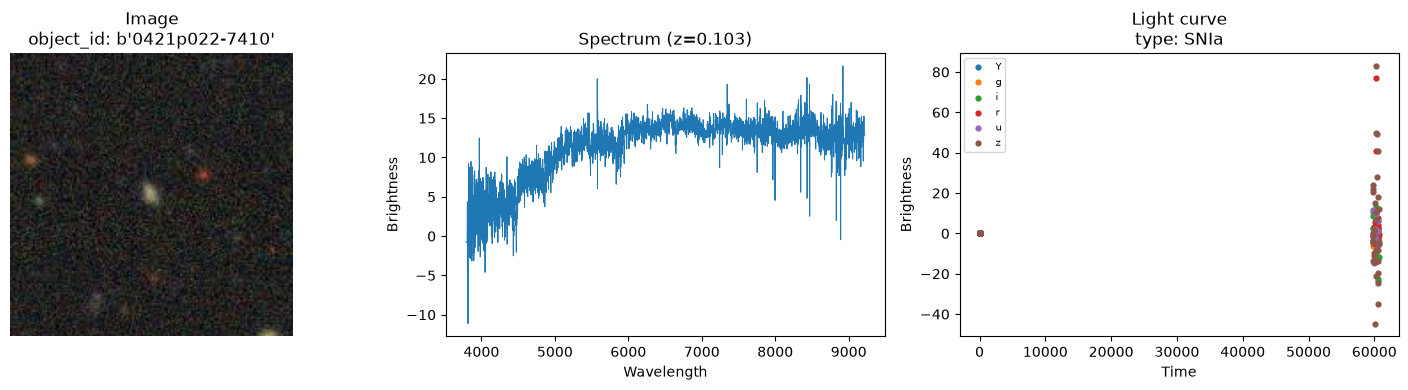

In [2]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np

# --- 1. IMAGE: a literal photo of a patch of sky ---
img_dset = load_dataset("MultimodalUniverse/legacysurvey", split="train", streaming=True)
img_ex = next(iter(img_dset.with_format("numpy")))

# --- 2. SPECTRUM: brightness split into a rainbow, plotted as a graph ---
spec_dset = load_dataset("MultimodalUniverse/sdss", split="train", streaming=True)
spec_ex = next(iter(spec_dset.with_format("numpy")))

# --- 3. LIGHT CURVE: brightness over time, plotted as a graph ---
lc_dset = load_dataset("MultimodalUniverse/plasticc", split="train", streaming=True)
lc_ex = next(iter(lc_dset.with_format("numpy")))

# --- Plot all three side by side ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Image: just show it
axes[0].imshow(img_ex['rgb'])
axes[0].set_title(f"Image\nobject_id: {img_ex['object_id']}")
axes[0].axis('off')

# Spectrum: brightness vs wavelength
spec = spec_ex['spectrum']
axes[1].plot(spec['lambda'], spec['flux'], linewidth=0.7)
axes[1].set_title(f"Spectrum (z={spec_ex['Z']:.3f})")
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("Brightness")

# Light curve: brightness vs time, colored by filter/band
lc = lc_ex['lightcurve']
for b in np.unique(lc['band']):
    mask = lc['band'] == b
    axes[2].scatter(lc['time'][mask], lc['flux'][mask], s=12, label=str(b))
axes[2].set_title(f"Light curve\ntype: {lc_ex['obj_type']}")
axes[2].set_xlabel("Time")
axes[2].set_ylabel("Brightness")
axes[2].legend(fontsize=7)

plt.tight_layout()
plt.show()

In [4]:
import lsdb
from lsdb.streams import CatalogStream

In [ ]:
gz10 = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_gz10")
sdss = lsdb.open_catalog("hf://datasets/UniverseTBD/mmu_sdss_sdss")

# So the line with compute essentially walks through every tile and does the full spatial join, handing us back a final pd/dask object (df)
# xmatch = gz10.crossmatch(sdss, n_neighbors=1).compute()
# This gets everything ready to stream as below
xmatch = gz10.crossmatch(sdss, n_neighbors=1)

/Users/gaurav/Desktop/Astrobridge/env/lib/python3.13/site-packages/lsdb/catalog/catalog.py:410: FutureWarning: The default suffix behavior will change from applying suffixes to all columns to only applying suffixes to overlapping columns in a future release.To maintain the current behavior, explicitly set `suffix_method='all_columns'`. To change to the new behavior, set `suffix_method='overlapping_columns'`.
  warnings.warn(


In [12]:
row = next(iter(CatalogStream(catalog=xmatch))).head(1).iloc[0]      

In [13]:
open("g.png", "wb").write(row["rgb_image_mmu_gz10"]["bytes"]) 

135255

In [11]:
row

rgb_image_mmu_gz10         {'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...
gz10_label_mmu_gz10                                                        5
                                                 ...                        
object_id_mmu_sdss_sdss                            b'   2573873494693537792'
_dist_arcsec                                                        0.054119
Name: 317759541996814100, Length: 38, dtype: object

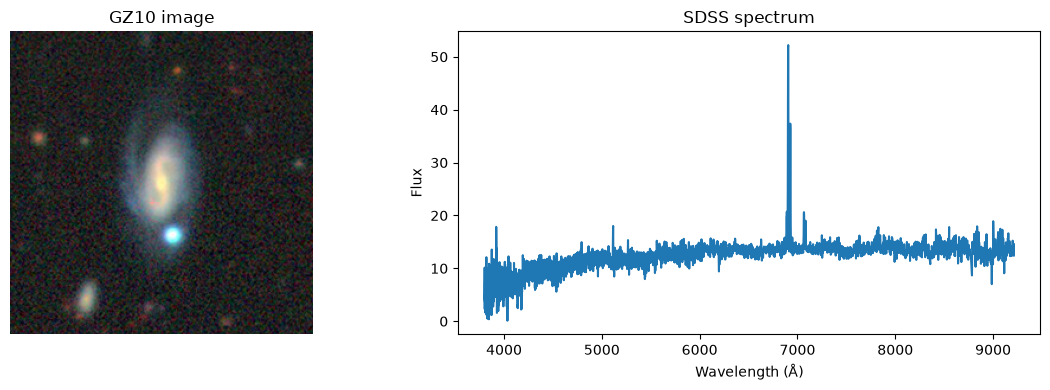

In [14]:
import matplotlib.pyplot as plt
import io
from PIL import Image

# spectrum
s = row["spectrum_mmu_sdss_sdss"]
s = s[~s["mask"]]        # drop masked/bad pixels

lambd = s["lambda"]      # wavelength array
flux  = s["flux"]        # flux array
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# panel 1: the galaxy image, properly decoded (not just the raw pixelated write)
img_bytes = row["rgb_image_mmu_gz10"]["bytes"]
img = Image.open(io.BytesIO(img_bytes))
axes[0].imshow(img)
axes[0].set_title("GZ10 image")
axes[0].axis("off")

# panel 2: the spectrum
axes[1].plot(lambd, flux)
axes[1].set_xlabel("Wavelength (Å)")
axes[1].set_ylabel("Flux")
axes[1].set_title("SDSS spectrum")

plt.tight_layout()
plt.savefig("pair.png", dpi=150)
plt.show()

In [ ]:
# moving along the iterator!

stream_iter = iter(CatalogStream(catalog=xmatch))
rows = []
for _ in range(5):
    partition = next(stream_iter)
    rows.append(partition.head(1).iloc[0])

In [ ]:
# Contents of a spectra entry?
s

,flux,ivar,lsf_sigma,lambda,mask
7,4.245453,0.068182,1.123208,3800.143555,False
8,7.902342,0.070759,1.122908,3801.018555,False
...,...,...,...,...,...
3852,14.645358,0.353845,0.746679,9210.856445,False
3853,12.437617,0.351526,0.746839,9212.977539,False
